In [ ]:
!tar -xf capsule.tar.xz

xz: (stdin): Unexpected end of input
tar: Unexpected EOF in archive
tar: Unexpected EOF in archive
tar: Error is not recoverable: exiting now


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!tar -xf "/content/drive/MyDrive/capsule.tar.xz" -C /content/

tar: /content/drive/MyDrive/capsule.tar.xz: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
print(os.listdir("/content/drive/MyDrive"))

['PASS.PDF', 'CERT.PDF', 'TRANS.PDF', '1679751421001.jpg', '1679751422027.jpg', 'AltaScanner_08_28_2023(1).pdf', 'crop.jpg', 'Classroom', 'Siya - 0918-note (71).gdoc', 'Siya - 0918-note (70).gdoc', 'Siya - 0918-note (69).gdoc', 'Siya - 0918-note (68).gdoc', 'Siya - 0918-note (67).gdoc', 'Siya - 0918-note (66).gdoc', 'Siya - 0918-note (65).gdoc', 'Siya - 0918-note (64).gdoc', 'Siya - 0918-note (63).gdoc', 'Siya - 0918-note (62).gdoc', 'Siya - 0918-note (61).gdoc', 'Siya - 0918-note (60).gdoc', 'Siya - 0918-note (59).gdoc', 'Siya - 0918-note (58).gdoc', 'Siya - 0918-note (57).gdoc', 'Siya - 0918-note (56).gdoc', 'Siya - 0918-note (55).gdoc', 'Siya - 0918-note (54).gdoc', 'Siya - 0918-note (53).gdoc', 'Siya - 0918-note (52).gdoc', 'Siya - 0918-note (51).gdoc', 'Siya - 0918-note (50).gdoc', 'Siya - 0918-note (49).gdoc', 'Siya - 0918-note (48).gdoc', 'Siya - 0918-note (47).gdoc', 'Siya - 0918-note (46).gdoc', 'Siya - 0918-note (45).gdoc', 'Siya - 0918-note (44).gdoc', 'Siya - 0918-note (43)

In [3]:
file_path = "/content/drive/MyDrive/capsule.tar.xz"

In [4]:
!tar -xf "/content/drive/MyDrive/capsule.tar.xz" -C /content/

In [5]:
print(os.listdir("/content"))
print(os.listdir("/content/capsule"))

['.config', 'drive', 'capsule', 'sample_data']
['ground_truth', 'license.txt', 'readme.txt', 'train', 'test']


In [6]:
import cv2
import numpy as np
import os

train_path = "/content/capsule/train/good"

IMG_SIZE = 128

def load_images(path):
    images = []
    for file in os.listdir(path):
        img = cv2.imread(os.path.join(path, file))
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        images.append(img)
    return np.array(images)

X_train = load_images(train_path)

print("Training shape:", X_train.shape)

Training shape: (219, 128, 128, 3)


In [7]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

input_img = Input(shape=(128,128,3))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,347 (52.14 KB)

 Trainable params: 13,347 (52.14 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
autoencoder.fit(
    X_train, X_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 482ms/step - loss: 0.0876 - val_loss: 0.0654
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0524 - val_loss: 0.0515
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0465 - val_loss: 0.0438
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0428 - val_loss: 0.0390
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0379 - val_loss: 0.0349
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0331 - val_loss: 0.0298
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0280 - val_loss: 0.0253
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0240 - val_loss: 0.0218
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0209 - val_loss: 0.0185
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0162 - val_loss: 0.0119


In [9]:
import matplotlib.pyplot as plt

good_test_path = "/content/capsule/test/good"
defect_test_path = "/content/capsule/test/crack"   # later we can also test scratch, poke, etc.

X_test_good = load_images(good_test_path)
X_test_defect = load_images(defect_test_path)

print("Good test shape:", X_test_good.shape)
print("Defect test shape:", X_test_defect.shape)

Good test shape: (23, 128, 128, 3)
Defect test shape: (23, 128, 128, 3)


In [10]:
recon_good = autoencoder.predict(X_test_good)
recon_defect = autoencoder.predict(X_test_defect)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 998ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [11]:
good_scores = np.mean((X_test_good - recon_good) ** 2, axis=(1,2,3))
defect_scores = np.mean((X_test_defect - recon_defect) ** 2, axis=(1,2,3))

print("Sample good scores:", good_scores[:5])
print("Sample defect scores:", defect_scores[:5])
print("Average good score:", np.mean(good_scores))
print("Average defect score:", np.mean(defect_scores))

Sample good scores: [0.01284357 0.01226386 0.01195602 0.01251513 0.01150619]
Sample defect scores: [0.01212799 0.01237591 0.01199556 0.01169759 0.01244658]
Average good score: 0.011866026377801837
Average defect score: 0.011546217765113146


In [15]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 8.6310e-04 - val_loss: 8.7531e-04
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 8.5936e-04 - val_loss: 7.9470e-04
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 8.8876e-04 - val_loss: 7.9300e-04
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 8.3449e-04 - val_loss: 7.8979e-04
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 7.9904e-04 - val_loss: 7.5588e-04
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 7.7709e-04 - val_loss: 7.4577e-04
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 7.9176e-04 - val_loss: 9.3980e-04
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 9.6672e-04 - val_loss: 0.0013
Epoch 9/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0011 - val_loss: 7.4374e-04
Epoch 10/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 8.7086e-04 - val_loss: 8.1753e-04
Epoch 11/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 7.6105e-04 - val_loss: 8.6450e-04
Epoch

In [16]:
IMG_SIZE = 256

In [23]:
autoencoder.input_shape

(None, 256, 256, 3)

In [32]:
from tensorflow.keras.layers import BatchNormalization

input_img = Input(shape=(256, 256, 3))

# Encoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

In [34]:
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

In [35]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=40,
    batch_size=32,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 917ms/step - loss: 0.0044 - val_loss: 0.0257
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - loss: 0.0015 - val_loss: 0.0198
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - loss: 8.5750e-04 - val_loss: 0.0153
Epoch 4/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step - loss: 6.8791e-04 - val_loss: 0.0131
Epoch 5/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - loss: 6.1501e-04 - val_loss: 0.0125
Epoch 6/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - loss: 5.4105e-04 - val_loss: 0.0125
Epoch 7/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - loss: 5.1727e-04 - val_loss: 0.0117
Epoch 8/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - loss: 5.3615e-04 - val_loss: 0.0124
Epoch 9/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - loss: 4.8072e-04 - val_loss: 0.0119
Epoch 10/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - loss: 4.7558e-04 - val_loss: 0.0124
Epoch 11/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - loss: 4.5732e-04 - val_loss: 0.0126
Epoch 12/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 

In [36]:
recon_good = autoencoder.predict(X_test_good)
recon_crack = autoencoder.predict(X_test_defect)

good_scores = np.mean((X_test_good - recon_good)**2, axis=(1,2,3))
crack_scores = np.mean((X_test_defect - recon_crack)**2, axis=(1,2,3))

print("Average good score:", np.mean(good_scores))
print("Average crack score:", np.mean(crack_scores))
print("Max good score:", np.max(good_scores))
print("Max crack score:", np.max(crack_scores))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Average good score: 0.0018584203878610813
Average crack score: 0.0019161166616652257
Max good score: 0.002071447067730461
Max crack score: 0.0024882510388742206


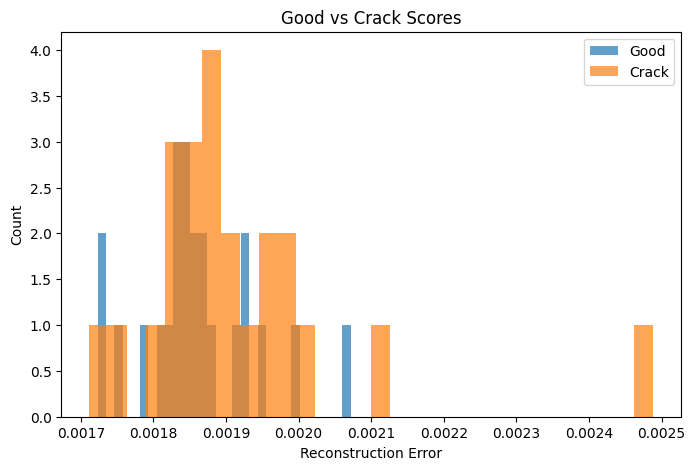

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(good_scores, bins=30, alpha=0.7, label="Good")
plt.hist(crack_scores, bins=30, alpha=0.7, label="Crack")
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("Good vs Crack Scores")
plt.legend()
plt.show()

In [38]:
threshold = np.mean(good_scores) + 2 * np.std(good_scores)
print("Threshold:", threshold)

Threshold: 0.002016004995462244


In [39]:
good_pred = (good_scores > threshold).astype(int)
crack_pred = (crack_scores > threshold).astype(int)

print("Good anomaly rate:", np.mean(good_pred) * 100, "%")
print("Crack anomaly rate:", np.mean(crack_pred) * 100, "%")

Good anomaly rate: 4.3478260869565215 %
Crack anomaly rate: 8.695652173913043 %


In [40]:
def show_heatmap(original, reconstructed, index=0):
    error_map = np.mean((original[index] - reconstructed[index])**2, axis=2)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(original[index])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(reconstructed[index])
    plt.title("Reconstructed")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(error_map, cmap="hot")
    plt.title("Error Heatmap")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

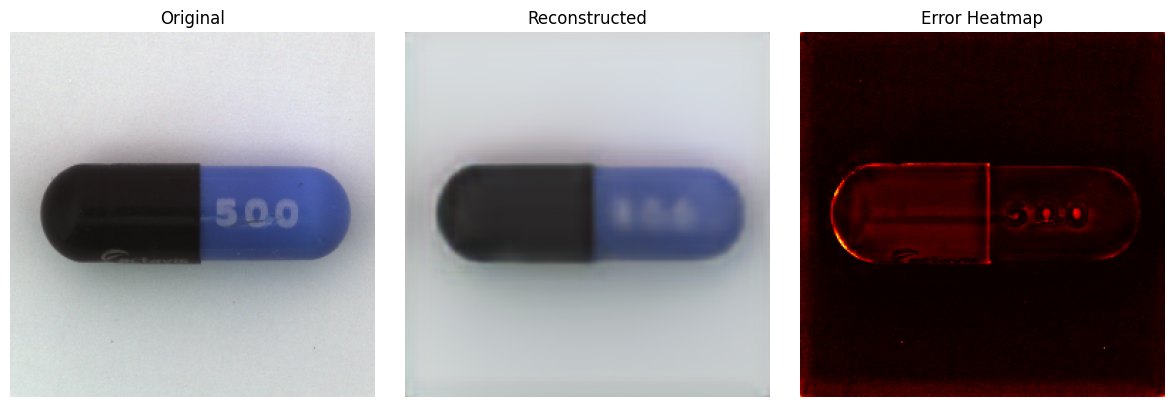

In [41]:
show_heatmap(X_test_defect, recon_crack, index=0)

In [42]:
def evaluate_defect(defect_name):
    path = f"/content/capsule/test/{defect_name}"
    X_def = load_images(path)
    recon_def = autoencoder.predict(X_def)
    scores_def = np.mean((X_def - recon_def)**2, axis=(1,2,3))
    print(defect_name, "mean score:", np.mean(scores_def), "| max score:", np.max(scores_def))
    return scores_def

scores_crack = evaluate_defect("crack")
scores_scratch = evaluate_defect("scratch")
scores_poke = evaluate_defect("poke")
scores_squeeze = evaluate_defect("squeeze")
scores_faulty = evaluate_defect("faulty_imprint")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
crack mean score: 0.0019161166616652257 | max score: 0.0024882510388742206
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
scratch mean score: 0.0018376860641581738 | max score: 0.0019873316457871427
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
poke mean score: 0.0018403511407962525 | max score: 0.0020129234258948643
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
squeeze mean score: 0.0019407188376666207 | max score: 0.002161595219831826
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step
faulty_imprint mean score: 0.0018167890496989273 | max score: 0.0019343803847909943


In [43]:
import pandas as pd

results = {
    "Category": ["Good", "Crack"],
    "Mean Score": [np.mean(good_scores), np.mean(crack_scores)],
    "Anomaly Rate (%)": [np.mean(good_pred)*100, np.mean(crack_pred)*100]
}

df = pd.DataFrame(results)
df

,Category,Mean Score,Anomaly Rate (%)
0,Good,0.001858,4.347826
1,Crack,0.001916,8.695652


In [44]:
autoencoder.save("/content/capsule_model.h5")